<a href="https://colab.research.google.com/github/ChristianAgyapong/Medgemma/blob/main/TASK_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import the tools we need**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

**Load the dataset ( no CSV needed)**

In [ ]:
# Public URL for Telco Churn (clean version, no customerID)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 3 rows:")
print(df.head(3))

print("\nTarget distribution:")
print(df['Churn'].value_counts(normalize=True))  # ~73% No, ~27% Yes → slightly imbalanced

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 3 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechS

**Prepare X (features) and y (target)**

In [ ]:
# Fix TotalCharges: replace empty strings with NaN, convert to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill small missing in TotalCharges with 0 (new customers)
df['TotalCharges'].fillna(0, inplace=True)

# Drop customerID if exists (not useful)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Convert binary Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Label encode simple categorical (or one-hot for better)
# For logistic: one-hot is better to avoid fake order
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)  # drop_first avoids multicollinearity

print("\nAfter preprocessing shape:", df.shape)
print("Churn value counts:", df['Churn'].value_counts())


After preprocessing shape: (7043, 31)
Churn value counts: Churn
0    5174
1    1869
Name: count, dtype: int64


/tmp/ipykernel_55/3482494138.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


**Split into train + test**

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for imbalanced classes
)

print("Train:", X_train.shape[0], "Test:", X_test.shape[0])

Train: 5634 Test: 1409


**Change words (categories) to numbers**

In [ ]:
scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']  # main continuous ones

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Numerical features scaled.")

Numerical features scaled.


**Scale (make numbers similar size) – Age and Fare only**

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)  # increased iter for convergence
model.fit(X_train, y_train)

print("Model trained! ✓")

Model trained! ✓


**Separate features (X) and target (y)**

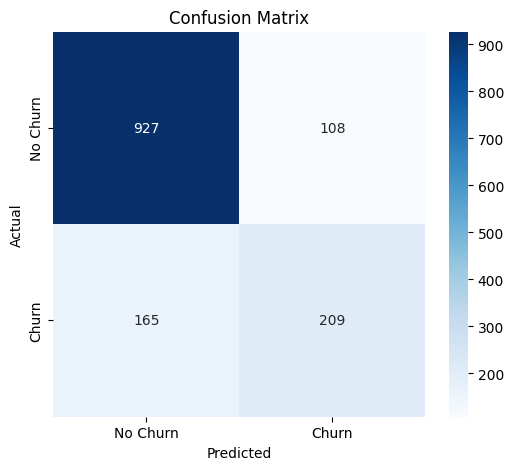

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of churn (class 1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}  (of predicted churners, how many really churned)")
print(f"Recall   : {rec:.3f}  (of real churners, how many we caught)")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.806
Precision: 0.659  (of predicted churners, how many really churned)
Recall   : 0.559  (of real churners, how many we caught)

Full Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



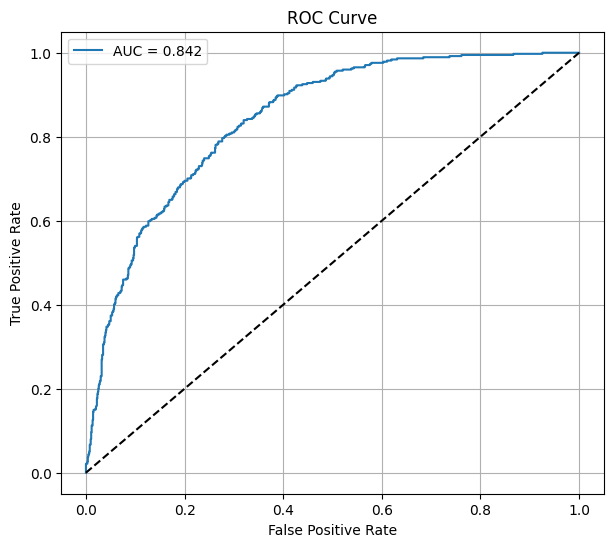

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--')  # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Coefficients DataFrame
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0].round(4)
}).sort_values('Coefficient', ascending=False)

print("Top positive coefficients (increase churn probability):")
print(coef_df.head(10))

print("\nTop negative coefficients (decrease churn probability):")
print(coef_df.tail(10))

# Odds ratios = exp(coefficient) → how much odds change per 1 unit increase
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient']).round(3)
print("\nWith Odds Ratios:")
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio']].head(10))

Top positive coefficients (increase churn probability):
                           Feature  Coefficient
10     InternetService_Fiber optic       1.1807
3                     TotalCharges       0.5278
28  PaymentMethod_Electronic check       0.3928
21                 StreamingTV_Yes       0.3748
26            PaperlessBilling_Yes       0.3742
23             StreamingMovies_Yes       0.3732
9                MultipleLines_Yes       0.3616
0                    SeniorCitizen       0.1479
29      PaymentMethod_Mailed check       0.0819
17            DeviceProtection_Yes       0.0331

Top negative coefficients (decrease churn probability):
                               Feature  Coefficient
12  OnlineSecurity_No internet service      -0.1725
6                       Dependents_Yes      -0.2264
8       MultipleLines_No phone service      -0.2693
19                     TechSupport_Yes      -0.2993
13                  OnlineSecurity_Yes      -0.3491
2                       MonthlyCharges      -0.